# Generalized Models

- Generalized Linear Models (GLMs)
- Generalized Additive Models (GAMs)

QUESTIONS:

- do i need to wait to scale with standard fit until after I split up my testing?
- what are the EDA checks I need to do for GAM?

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
%pip install pygam
from pygam import LinearGAM, GammaGAM, s, f


You should consider upgrading via the '/Users/jothigupta/sem_1/XAI/Assumption-junction/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


The first step is to upload the csv file data into our dataframe

In [22]:
CSV_FILE = "kaggle_data"

customer_df = pd.read_csv(CSV_FILE)
customer_df.head(10)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## Cleaning up the data

In [23]:
# Checking if there are any repeat customer
unique_customers = customer_df["customerID"].nunique()
rows = customer_df.count()

print(unique_customers)
print(rows["customerID"])


# Checking data type of each column
print(customer_df.dtypes)

# Checking presence of N/As
na_counts = customer_df.isnull().sum()
print(na_counts)


7043
7043
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod 

Since the number of unique customers is equal to the number of total customers, we can conclude that there are no repeat customers and thus are safe to remove that column in the dataset.

In [24]:
# Remove customerID
clean_df = customer_df.copy()
clean_df = clean_df.drop(columns=['customerID'])

clean_df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Applying One-Hot Encoding to the categorical variables.

In [25]:
# Checking unique values of each categorical variable
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
for col in categorical_cols:
    unique = clean_df[col].unique()
    print(f"Unique values in {col}: {unique}, count = {len(unique)}")

# Normalizing categorical variables
clean_df = pd.get_dummies(clean_df, columns=categorical_cols, drop_first=True)
clean_df.head(10)

Unique values in gender: ['Female' 'Male'], count = 2
Unique values in SeniorCitizen: [0 1], count = 2
Unique values in Partner: ['Yes' 'No'], count = 2
Unique values in Dependents: ['No' 'Yes'], count = 2
Unique values in PhoneService: ['No' 'Yes'], count = 2
Unique values in MultipleLines: ['No phone service' 'No' 'Yes'], count = 3
Unique values in InternetService: ['DSL' 'Fiber optic' 'No'], count = 3
Unique values in OnlineSecurity: ['No' 'Yes' 'No internet service'], count = 3
Unique values in OnlineBackup: ['Yes' 'No' 'No internet service'], count = 3
Unique values in DeviceProtection: ['No' 'Yes' 'No internet service'], count = 3
Unique values in TechSupport: ['No' 'Yes' 'No internet service'], count = 3
Unique values in StreamingTV: ['No' 'Yes' 'No internet service'], count = 3
Unique values in StreamingMovies: ['No' 'Yes' 'No internet service'], count = 3
Unique values in Contract: ['Month-to-month' 'One year' 'Two year'], count = 3
Unique values in PaperlessBilling: ['Yes' 'N

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,1,29.85,29.85,False,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,34,56.95,1889.5,True,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,2,53.85,108.15,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,45,42.30,1840.75,True,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,2,70.70,151.65,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True
5,8,99.65,820.5,False,False,False,False,True,False,True,...,True,False,True,False,False,True,False,True,False,True
6,22,89.10,1949.4,True,False,False,True,True,False,True,...,True,False,False,False,False,True,True,False,False,False
7,10,29.75,301.9,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
8,28,104.80,3046.05,False,False,True,False,True,False,True,...,True,False,True,False,False,True,False,True,False,True
9,62,56.15,3487.95,True,False,False,True,True,False,False,...,False,False,False,True,False,False,False,False,False,False


Scaling numerical variables using StandardScaler().

In [ ]:
# Handling numerical variables
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

clean_df.head(10)



,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,1,29.85,29.85,False,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,34,56.95,1889.50,True,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,2,53.85,108.15,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,45,42.30,1840.75,True,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,2,70.70,151.65,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True
5,8,99.65,820.50,False,False,False,False,True,False,True,...,True,False,True,False,False,True,False,True,False,True
6,22,89.10,1949.40,True,False,False,True,True,False,True,...,True,False,False,False,False,True,True,False,False,False
7,10,29.75,301.90,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
8,28,104.80,3046.05,False,False,True,False,True,False,True,...,True,False,True,False,False,True,False,True,False,True
9,62,56.15,3487.95,True,False,False,True,True,False,False,...,False,False,False,True,False,False,False,False,False,False


## Exploratory Data Analysis

### Test 1: Linearize numerical variables against Churn

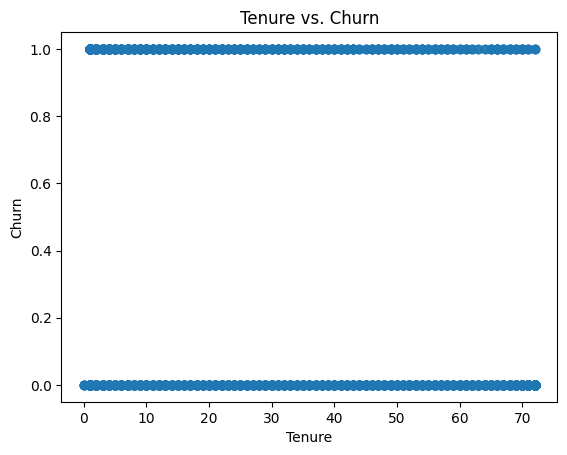

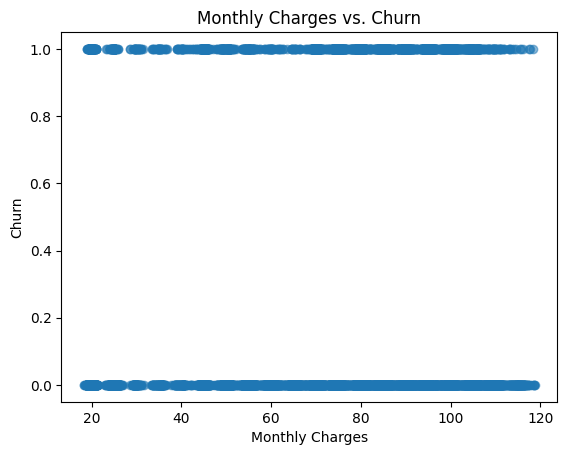

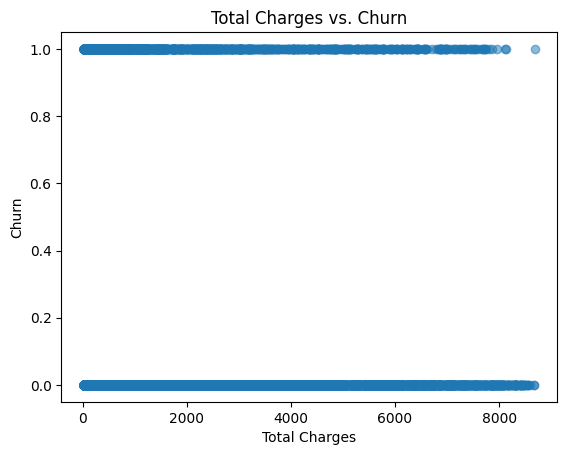

In [27]:
# exploring relationship between numerical variables and churn
plt.scatter(clean_df['tenure'], clean_df['Churn_Yes'], alpha=0.5)
plt.xlabel("Tenure")
plt.ylabel("Churn")
plt.title("Tenure vs. Churn")
plt.show()

plt.scatter(clean_df['MonthlyCharges'], clean_df['Churn_Yes'], alpha=0.5)
plt.xlabel("Monthly Charges")
plt.ylabel("Churn")
plt.title("Monthly Charges vs. Churn")
plt.show()

plt.scatter(clean_df['TotalCharges'], clean_df['Churn_Yes'], alpha=0.5)
plt.xlabel("Total Charges")
plt.ylabel("Churn")
plt.title("Total Charges vs. Churn")
plt.show()


The variables largely failed to linearize given that Churn is a categorical variable, so it's hard to get meaningful inferences when only between two variables.

## Building the GAM model


In [35]:
# Loading the data
clean_df = clean_df.dropna()
non_target = clean_df.drop(columns='Churn_Yes')
X, y = non_target, clean_df['Churn_Yes']


# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling training data
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Handling NA's
#X_train = X_train.dropna()
#X_test = X_test.dropna()

# Initializing GAM set-up
gam = LinearGAM(s(0) + s(1) + s(2) + s(3) + f(4) + f(5) + f(6) + f(6) + f(7) + f(8) + f(9) + f(10) + f(11) + f(12) + f(13) + f(14) + f(15) + f(16) + f(17) + f(18))

# Find best smoothing parameters for each spline term
gam.gridsearch(X_train, y_train)

# Fit the model
gam.fit(X_train, y_train)

# Make predictions
y_pred_gam = gam.predict(X_test)

# Calculate MSE and R^2
mse_gam = mean_squared_error(y_test, y_pred_gam)
r2_gam = r2_score(y_test, y_pred_gam)

print(f"GAM MSE: {mse_gam:.4f}, R^2: {r2_gam:.4f}")

gam.summary()


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
/Users/jothigupta/sem_1/XAI/Assumption-junction/.venv/lib/python3.10/site-packages/scipy/linalg/_basic.py:1622: RuntimeWarning: divide by zero encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/jothigupta/sem_1/XAI/Assumption-junction/.venv/lib/python3.10/site-packages/scipy/linalg/_basic.py:1622: RuntimeWarning: overflow encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/jothigupta/sem_1/XAI/Assumption-junction/.venv/lib/python3.10/site-packages/scipy/linalg/_basic.py:1622: RuntimeWarning: invalid value encountered in matmul
  B = (u @ vh[:rank]).conj().T
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:04
/Users/jothigupta/sem_1/XAI/Assumption-junction/.venv/lib/python3.10/site-packages/scipy/linalg/_basic.py:1622: RuntimeWarning: divide by zero encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/jothigupta/sem_1/XAI/Assumption-junction/.venv/lib/pytho

GAM MSE: 0.1439, R^2: 0.2626
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     33.5736
Link Function:                     IdentityLink Log Likelihood:                                 -2374.6422
Number of Samples:                         5625 AIC:                                             4818.4317
                                                AICc:                                            4818.8717
                                                GCV:                                                0.1385
                                                Scale:                                              0.3702
                                                Pseudo R-Squared:                                    0.302
Feature 

/Users/jothigupta/sem_1/XAI/Assumption-junction/.venv/lib/python3.10/site-packages/scipy/linalg/_basic.py:1622: RuntimeWarning: divide by zero encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/jothigupta/sem_1/XAI/Assumption-junction/.venv/lib/python3.10/site-packages/scipy/linalg/_basic.py:1622: RuntimeWarning: overflow encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/jothigupta/sem_1/XAI/Assumption-junction/.venv/lib/python3.10/site-packages/scipy/linalg/_basic.py:1622: RuntimeWarning: invalid value encountered in matmul
  B = (u @ vh[:rank]).conj().T
/var/folders/22/gw1lzr951bg3gb6mtgvz8xfh0000gn/T/ipykernel_58771/1860795649.py:37: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


### Visualize GAM

20


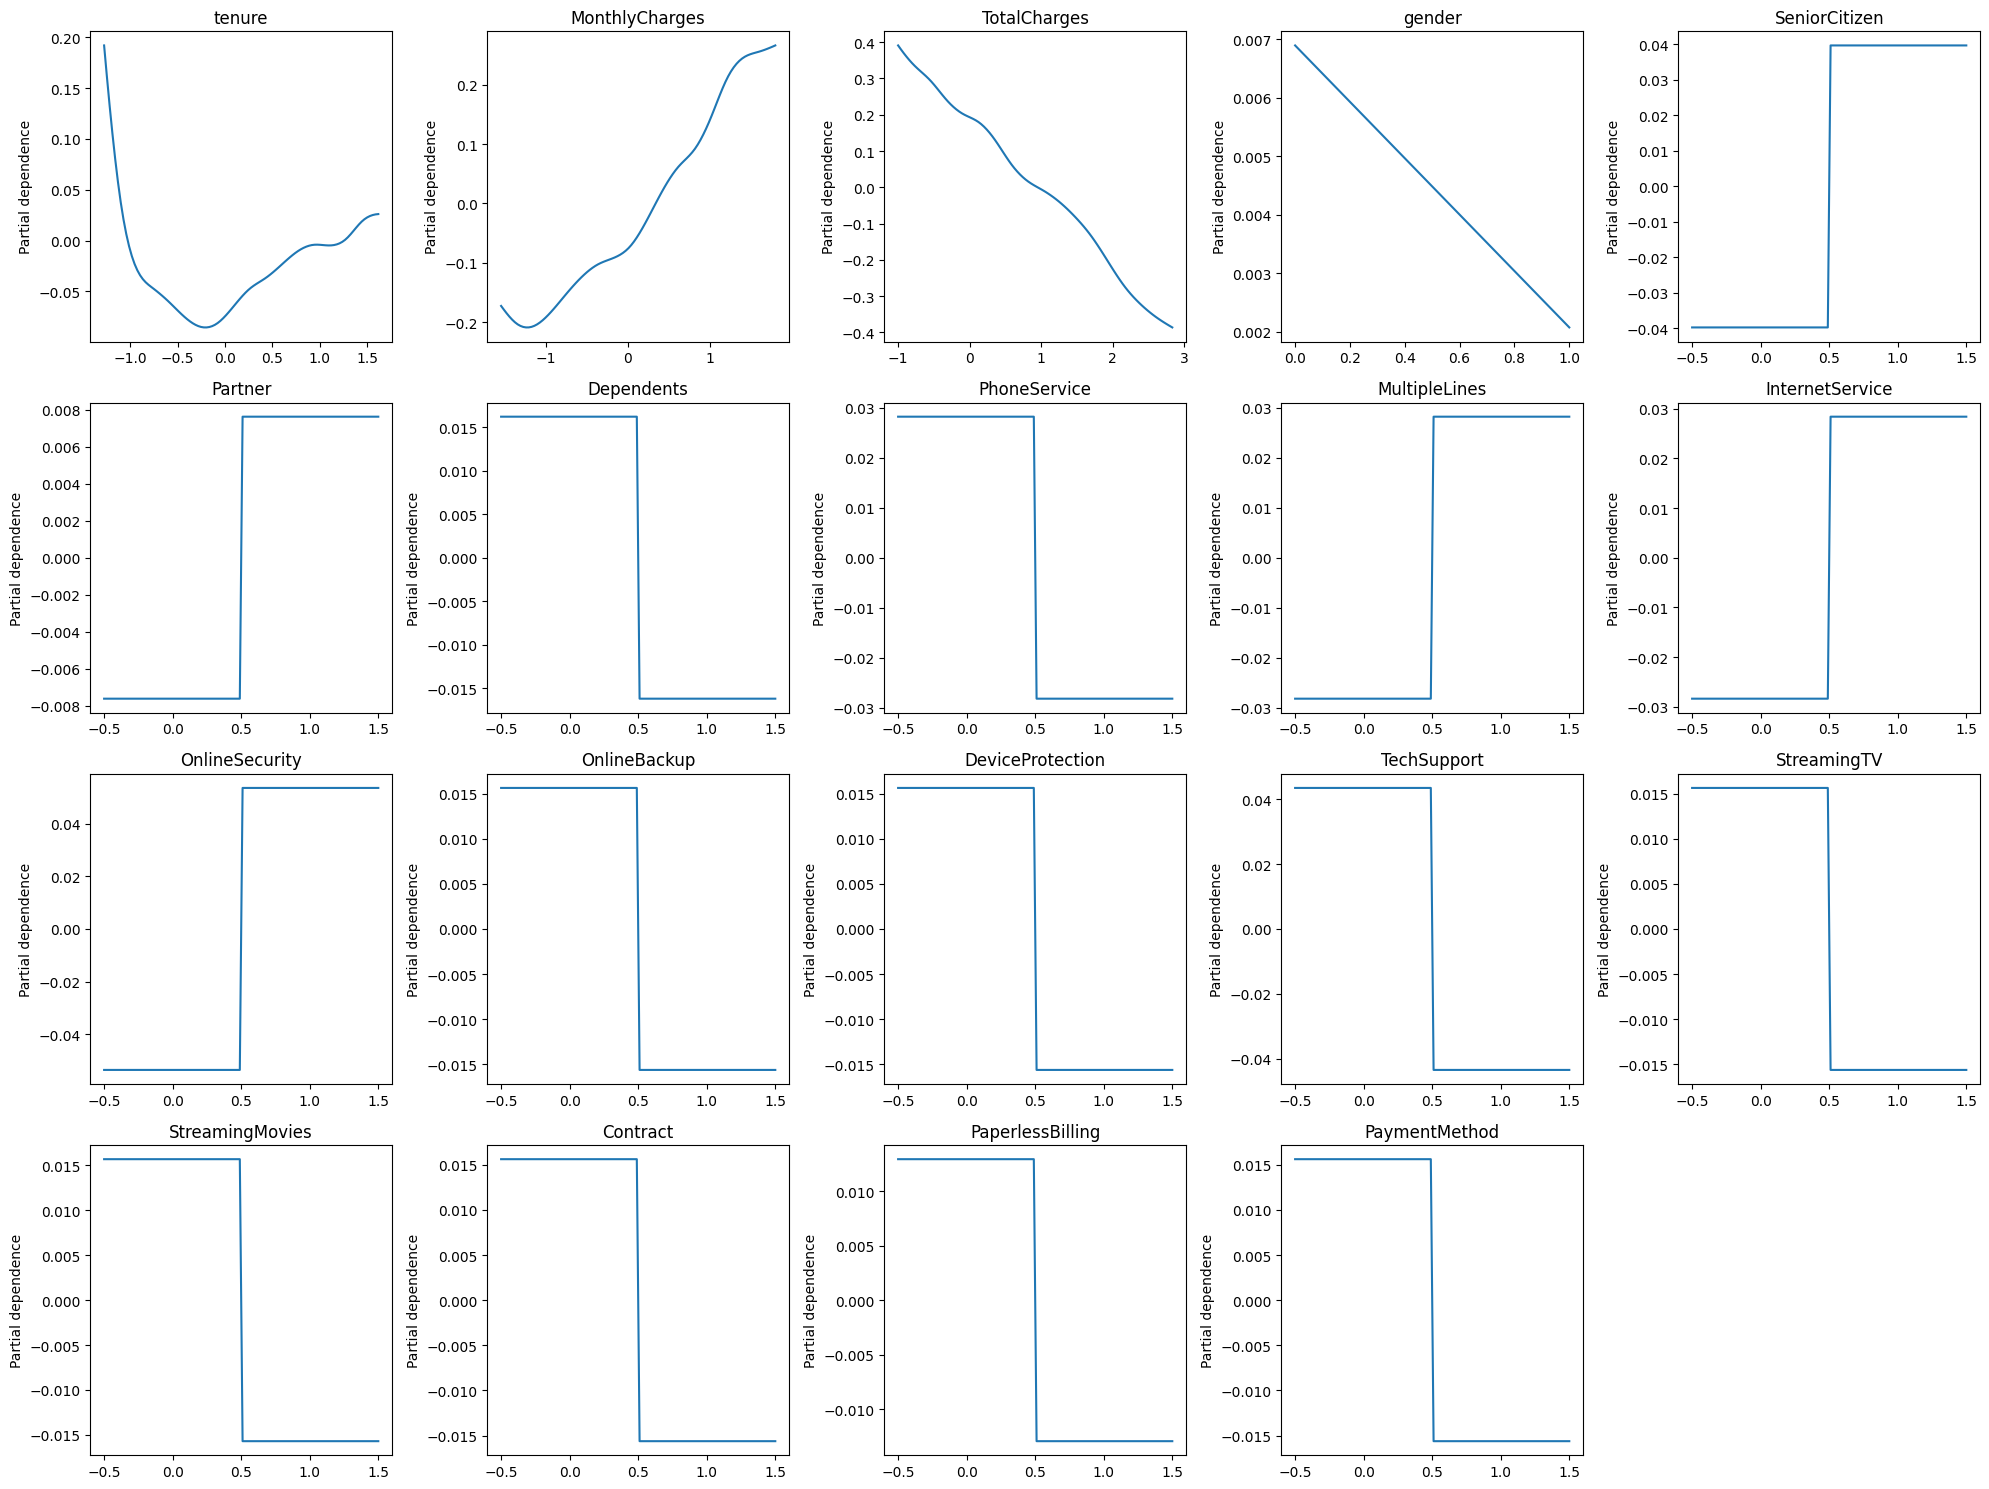

In [42]:
# Plotting GAM model
plt.figure(figsize=(20,15))
plot_terms = [term for term in gam.terms if not term.isintercept]
n_terms = len(plot_terms)

print(len(gam.terms))
cols = numerical_cols + categorical_cols

plot_idx = 1
for term in gam.terms:
    if term.isintercept:
        continue
    plt.subplot(4, 5, plot_idx)
    XX = gam.generate_X_grid(term=term.feature)
    plt.plot(XX[:, term.feature], gam.partial_dependence(term=term.feature, X=XX))
    plt.title(cols[term.feature])
    plt.ylabel('Partial dependence')
    plot_idx += 1

plt.tight_layout()
plt.show()

## Assessing GAM

The smooth effect was most useful for the numerical variables and most useless for the categorical variables. In regards to the categorical variables, it merely shows us whether the relationship is direct or inverse since it's only a decision between two outcomes. But the smoothing effect on the numerical variables is very useful. It seems that total charges and monthly charges has an inverse relationship. A higher total charges is associated with a lower likelihood of churning, while the opposite is true of high monthly charge. Tenure is different, where the trend reflects more of an inverse bell curve. The tenure feature shows how tenure is usefully demonstrated by the GAM model, but the GAM model may not be necessary for the other numerical features which have a more simplistic relationship.  

### Limitations of GAM

A limitation of GAM is that it doesn't handle many categorical variables very well and it's hard to gain meaning from the output performance of the categorical variables in the GAM model. 